#### Tissera Ana Paula - `Notebook TP3`

In [343]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


##### Imports

In [344]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import os
import itertools


In [345]:
SEED = 42

### `1.` **Análisis y Preprocesamiento de Datos**

In [346]:
X_images = np.load("data/X_images.npy")
y_images = np.load("data/y_images.npy")


In [347]:
print("Forma de X:", X_images.shape)
print("Forma de y:", y_images.shape)
print("Etiquetas únicas:", np.unique(y_images))

Forma de X: (5000, 784)
Forma de y: (5000,)
Etiquetas únicas: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48]


### Visualización de imágenes

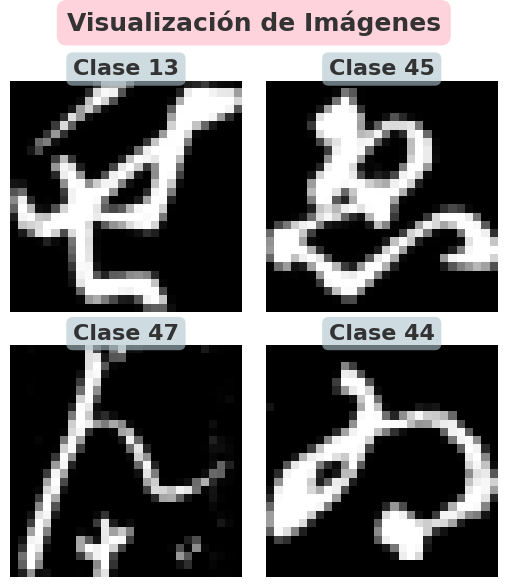

In [348]:
from src.plot import plot_images

name_map = {i: f"Clase {i}" for i in np.unique(y_images)}

# # Llamada al plot
# plot_images(
#     X_images, y_images,
#     indices=list(range(8)),       # muestra las primeras 12
#     n_cols=4,                      # 4 columnas → 3 filas
#     cmap='gray',
#     figsize_scale=2.5,
#     title_bg_color='#AEDFF7',      
#     title_color='#333333',
#     title_alpha=0.6,
#     suptitle="Ejemplo de Imágenes",
#     suptitle_bg='#FCC9B9',         
#     suptitle_color='#333333',
#     suptitle_alpha=0.6,
#     name_map=name_map
# )

np.random.seed(SEED)
clases = np.unique(y_images)
clases_seleccion = np.random.choice(clases, size=4, replace=False)
indices = []
for cl in clases_seleccion:
    idxs_cl = np.where(y_images == cl)[0]
    indices.append(int(np.random.choice(idxs_cl)))

name_map = {i: f"Clase {i}" for i in np.unique(y_images)}

plot_images(
    X_images, y_images,
    indices=indices,         
    n_cols=2,               # número de imágenes     
    suptitle="Visualización de Imágenes",
    name_map=name_map,
    random_seed=SEED
)

In [349]:
print("▶ X:", type(X_images), "shape =", X_images.shape, "dtype =", X_images.dtype)
print("▶ y:", type(y_images), "shape =", y_images.shape, "dtype =", y_images.dtype)

# Si X está aplanado, chequeá min/max
print("▶ X min/max:", X_images.min(), "/", X_images.max())

▶ X: <class 'numpy.ndarray'> shape = (5000, 784) dtype = float32
▶ y: <class 'numpy.ndarray'> shape = (5000,) dtype = int64
▶ X min/max: 0.0 / 255.0


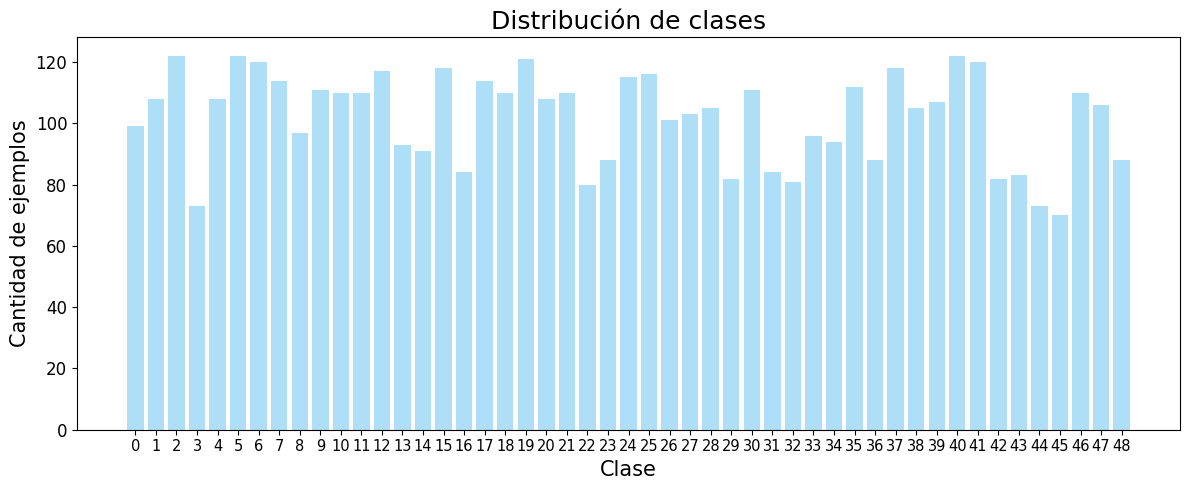

In [350]:
from src.plot import plot_class_distribution
plot_class_distribution(y_images, name_map=name_map, figsize=(12, 5), color='#AEDFF7')

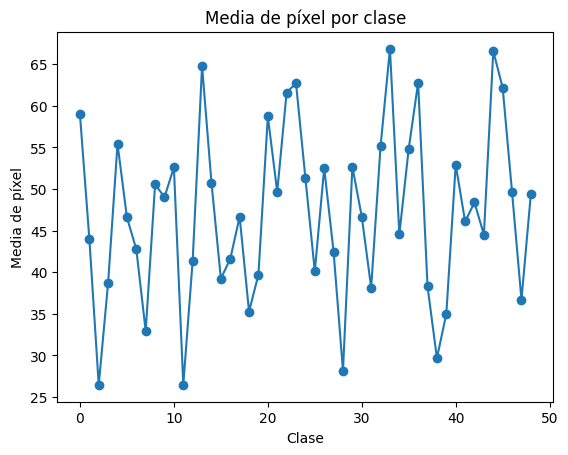

In [351]:
medias = [X_images[y_images==cl].mean() for cl in clases]
plt.plot(clases, medias, marker='o')
plt.xlabel("Clase")
plt.ylabel("Media de píxel")
plt.title("Media de píxel por clase")
plt.show()

In [352]:
print("Media de píxeles en todo X:", X_images.mean())
print("Desviación estándar de píxeles:", X_images.std())

Media de píxeles en todo X: 46.525486
Desviación estándar de píxeles: 87.565414


#### División del dataset


In [353]:
from src.data_splitting import split_data

X_dev, y_dev, X_test, y_test = split_data(X_images, y_images, ratio=0.2, seed=SEED)

X_train, y_train, X_val, y_val = split_data(X_dev, y_dev, ratio=0.2, seed=SEED)


#### Normalización

In [354]:
X_train = X_train.astype(np.float32) / 255.0
X_val   = X_val.astype(np.float32)   / 255.0
X_test  = X_test.astype(np.float32)  / 255.0
X_dev   = X_dev.astype(np.float32)   / 255.0

out_dir = "data/processed"
os.makedirs(out_dir, exist_ok=True)

np.savez_compressed(os.path.join(out_dir, "train.npz"), X=X_train, y=y_train)
np.savez_compressed(os.path.join(out_dir, "val.npz"),   X=X_val,   y=y_val)
np.savez_compressed(os.path.join(out_dir, "test.npz"),  X=X_test,  y=y_test)

### `2.` **Implementación y Entrenamiento de una Red Neuronal Básica**

red neuronal con 2 capas ocultas, con 100 y 80 nodos

In [355]:
from src.Neural_Network import NeuralNetwork

Epochs: 100%|██████████| 1000/1000 [01:15<00:00, 13.23it/s]


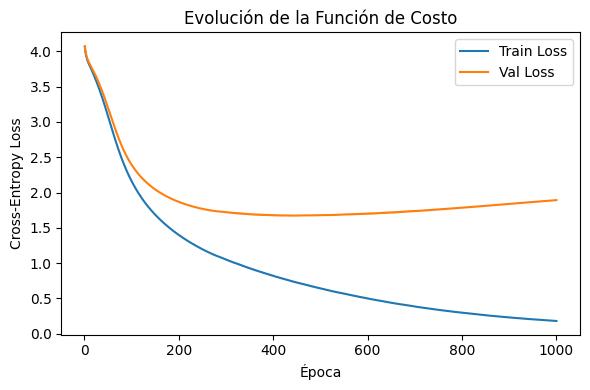

In [356]:

# Parámetros de M0
input_size    = X_train.shape[1]
hidden1, hidden2 = 100, 80
n_classes     = int(np.max(y_train)) + 1
epochs        = 1000

# One-hot encoding
Y_train_oh = np.eye(n_classes)[y_train]
Y_val_oh   = np.eye(n_classes)[y_val]


M0 = NeuralNetwork(
    layer_sizes=[input_size, hidden1, hidden2, n_classes],
    learning_rate=0.1,
    seed=SEED
)

train_losses, val_losses = M0.train_bp(
    X_train, Y_train_oh,
    X_val= X_val, Y_val=Y_val_oh,
    epochs=epochs,
    plot=True
)


### Métricas en Conjunto de Entrenamiento
**Accuracy:** 0.9862  
**Cross-Entropy Loss:** 0.1789  


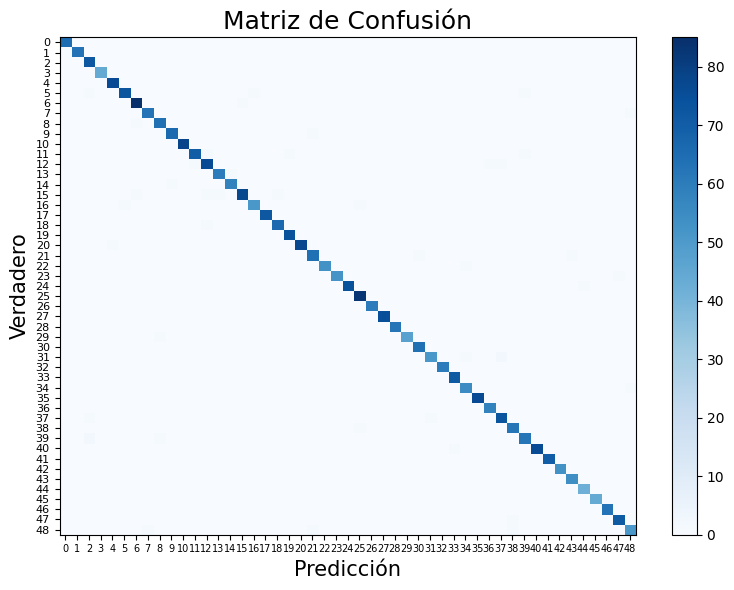

### Métricas en Conjunto de Validación
**Accuracy:** 0.5950  
**Cross-Entropy Loss:** 1.8923  


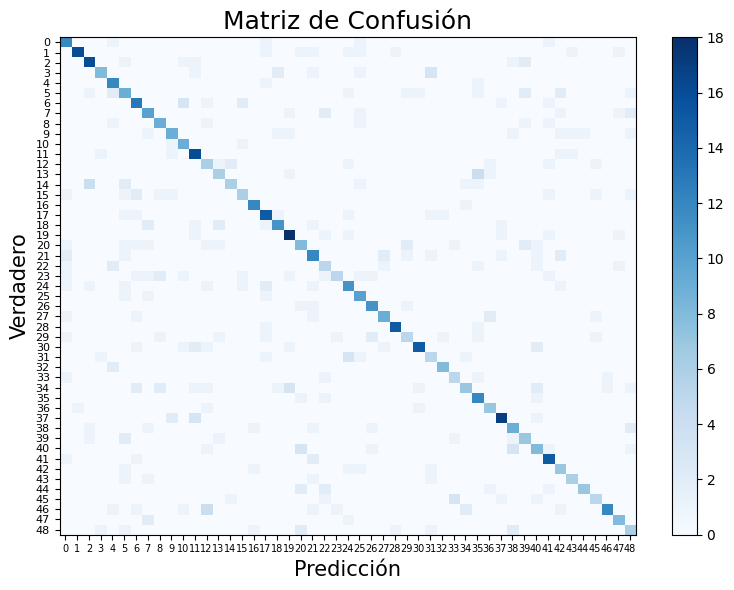

In [357]:

from src.metrics import Metrics  # importa la clase que guardaste en metrics.py

# 1) Calcula predicciones “duro” (etiquetas) y predicciones “blando” (probabilidades)

Y_hat_train = M0.forward(X_train)      # shape (n_classes, m_train)
y_proba_train = Y_hat_train.T          # shape (m_train, n_classes)
y_pred_train  = np.argmax(Y_hat_train, axis=0)  # shape (m_train,)

#    – Para validación:
Y_hat_val   = M0.forward(X_val)        # shape (n_classes, m_val)
y_proba_val = Y_hat_val.T              # shape (m_val, n_classes)
y_pred_val  = np.argmax(Y_hat_val, axis=0)      # shape (m_val,)

# 2) Crea y muestra las métricas con la clase Metrics
#    Puedes pasarle también la lista de labels si quieres un orden específico;
#    si no, los infiere de y_true/y_pred.

# Métricas en entrenamiento
met_train = Metrics(
    y_true=y_train,
    y_pred=y_pred_train,
    y_proba=y_proba_train
)
met_train.report_metrics(title="Métricas en Conjunto de Entrenamiento", show_matrix_table = False, plot_matrix_heatmap= True)

# Métricas en validación
met_val = Metrics(
    y_true=y_val,
    y_pred=y_pred_val,
    y_proba=y_proba_val
)
met_val.report_metrics(title="Métricas en Conjunto de Validación")


### `3.` **Implementación y Entrenamiento de una Red Neuronal Avanzada**

In [358]:
from src.Neural_Network import NeuralNetwork

In [ ]:

configs = {
    'Batch GD':               {'optimizer':'gd'},
    'Rate Scheduling Lineal': {'lr_schedule': 'linear', 'learning_rate':0.2},
    'Rate Scheduling Exp':    {'lr_schedule': 'exp', 'learning_rate':0.2},
    'Stochastic GD':          {'optimizer':'sgd', 'learning_rate':0.01},
    'Mini-batch GD':          {'optimizer':'mb', 'batch_size':32},
    # Mini-batch stochastic gradient descent?
    'Adam':                   {'optimizer':'adam', 'learning_rate':0.01},
    'L2 (λ=1e-3)':            {'l2_lambda':1e-3},
    'EarlyStop (p=5)':        {'early_stopping':True,'patience':5},
    'Dropout (p=0.2)':        {'dropout_p':0.2},
    'BatchNorm':              {'use_batchnorm':True},
}

results = []

for name, params in configs.items():
 
    nn = NeuralNetwork(
        layer_sizes=[input_size, hidden1, hidden2, n_classes],
        learning_rate=params.get('learning_rate', 0.1),
        seed=SEED,
        optimizer=params.get('optimizer', 'gd'),
        batch_size=params.get('batch_size', None),
        l2_lambda=params.get('l2_lambda', 0.0),
        dropout_p=params.get('dropout_p', 0.0),
        use_batchnorm=params.get('use_batchnorm', False),
        early_stopping=params.get('early_stopping', False),
        patience=params.get('patience', 5),
    )
    
    # definir scheduler
    lr_schedule = None
    if params.get('lr_schedule') == 'linear':
        lr_schedule = nn.get_linear_schedule(final_lr=0.001, max_epochs=epochs)
    elif params.get('lr_schedule') == 'exp':
        lr_schedule = nn.get_exponential_schedule(decay_rate=0.05)
        
    # entrenar
    nn.train_bp(
        X_train, Y_train_oh,
        X_val=X_val, Y_val=Y_val_oh,
        epochs=epochs,
        plot=False,
        lr_schedule=lr_schedule
    )
    
    # 3) Calcular métricas
    # train
    Yhat_tr = nn.forward(X_train, train=False)
    yproba_tr = Yhat_tr.T
    ypred_tr  = np.argmax(Yhat_tr, axis=0)
    m_tr = Metrics(y_true=y_train, y_pred=ypred_tr, y_proba=yproba_tr)
    acc_tr = m_tr.accuracy()
    ce_tr  = m_tr.cross_entropy()
    # val
    Yhat_v = nn.forward(X_val, train=False)
    yproba_v = Yhat_v.T
    ypred_v  = np.argmax(Yhat_v, axis=0)
    m_v = Metrics(y_true=y_val, y_pred=ypred_v, y_proba=yproba_v)
    acc_v = m_v.accuracy()
    ce_v  = m_v.cross_entropy()

    results.append((name, acc_tr, ce_tr, acc_v, ce_v))

# 4) Montar la tabla Markdown
header = "|Método|Acc Train|CE Loss Train|Acc Val|CE Loss Val|\n"
sep    = "|" + "---|"*5 + "\n"
rows   = ""
for name, at, ct, av, cv in results:
    rows += f"|{name}|{at:.4f}|{ct:.4f}|{av:.4f}|{cv:.4f}|\n"

table_md = header + sep + rows

# 5) Mostrar
display(Markdown("## Comparativa de Métricas"))
display(Markdown(table_md))

Epochs:  94%|█████████▍| 940/1000 [01:17<00:05, 11.11it/s]

In [ ]:
architectures = [
    # Redes ligeras (rápidas de entrenar, menos parámetros)
    [input_size, 32, n_classes],
    [input_size, 64, n_classes],
    [input_size, 64, 32, n_classes],
    
    # Redes de complejidad media (equilibrio)
    [input_size, 100, n_classes],
    [input_size, 128, 64, n_classes],
    [input_size, 100, 50, n_classes],
    [input_size, 64, 64, 32, n_classes],
    
    # Redes más profundas (más capacidad, más lentas)
    [input_size, 150, 80, n_classes],
    [input_size, 128, 64, 32, n_classes],
    [input_size, 256, 128, 64, n_classes],

    # Arquitecturas alternativas con tres capas ocultas
    [input_size, 100, 50, 25, n_classes],
    [input_size, 128, 128, 64, 32, n_classes],
]

# Hiperparámetros base (los valores por defecto de configs más los extra que necesites)
hyperparams = {
    'optimizer':       ['gd', 'sgd', 'mb', 'adam'],
    'learning_rate':   [0.001, 0.01, 0.05, 0.1, 0.15, 0.2, 0.4],
    'batch_size':      [None, 16, 32, 64, 128, 256],        # solo importa cuando optimizer='mb'
    'l2_lambda':       [0.0, 1e-3, 1e-2, 1e-1, 1],
    'dropout_p':       [0.0, 0.1, 0.15, 0.2, 0.25, 0.3],
    'use_batchnorm':   [False, True],
    'early_stopping':  [False, True],
    'patience':        [5, 10, 15, 20, 50],               # solo si early_stopping=True
    'lr_schedule':     ['none', 'linear', 'exp'],
}

# 2) Función auxiliar para instanciar el scheduler
def get_schedule(nn, name, epochs):
    if name == 'linear':
        return nn.get_linear_schedule(final_lr=0.001, max_epochs=epochs)
    if name == 'exp':
        return nn.get_exponential_schedule(decay_rate=0.05)
    return None

# 3) Grid search
results = []
epochs = 3000

for arch in architectures:
    for (opt, lr, bs, l2, do_p, bn, es, pat, sched) in itertools.product(
        hyperparams['optimizer'],
        hyperparams['learning_rate'],
        hyperparams['batch_size'],
        hyperparams['l2_lambda'],
        hyperparams['dropout_p'],
        hyperparams['use_batchnorm'],
        hyperparams['early_stopping'],
        hyperparams['patience'],
        hyperparams['lr_schedule'],
    ):
        # Ajustes condicionales
        if opt != 'mb' and bs is not None:
            continue
        if not es and pat != 5:
            continue
        # Crea la red
        nn = NeuralNetwork(
            layer_sizes=arch,
            learning_rate=lr,
            seed=SEED,
            optimizer=opt,
            batch_size=bs,
            l2_lambda=l2,
            dropout_p=do_p,
            use_batchnorm=bn,
            early_stopping=es,
            patience=pat,
        )
        # Scheduler
        lr_fn = get_schedule(nn, sched, epochs)
        # Entrenamiento
        nn.train_bp(
            X_train, Y_train_oh,
            X_val=X_val, Y_val=Y_val_oh,
            epochs=epochs,
            plot=False,
            lr_schedule=lr_fn
        )
        # Evaluación
        Yhat_v = nn.forward(X_val, train=False)
        yproba_v = Yhat_v.T
        ypred_v  = np.argmax(Yhat_v, axis=0)
        met_v = Metrics(y_true=y_val, y_pred=ypred_v, y_proba=yproba_v)
        acc_v = met_v.accuracy()
        ce_v  = met_v.cross_entropy()
        # Guarda resultado
        results.append({
            'arch':              str(arch),
            'optimizer':         opt,
            'learning_rate':     lr,
            'batch_size':        bs,
            'l2_lambda':         l2,
            'dropout_p':         do_p,
            'use_batchnorm':     bn,
            'early_stopping':    es,
            'patience':          pat,
            'lr_schedule':       sched,
            'val_accuracy':      acc_v,
            'val_crossentropy':  ce_v,
        })

# 4) Monta un DataFrame y elige la mejor configuración
df = pd.DataFrame(results)
best = df.sort_values('val_crossentropy').iloc[0]

print("Mejor configuración (menor CE en validación):")
print(best.to_dict())

KeyboardInterrupt: 